# Association Rule Mining with Apriori (FP-Growth) in Apache Spark

This notebook applies association rule mining on an e-commerce dataset using **PySpark's FP-Growth**, which produces the same output as Apriori (frequent itemsets + association rules) but is optimized for distributed environments.

> **Dataset**: E-commerce event log (~135K rows) with columns: `event_type`, `product_id`, `brand`, `price`, `user_id`, `user_session`, `product_name`, `category`, `hour`, `day`, `month`, `year`

## Pipeline Overview
1. Initialize Spark Session
2. Load & Explore Data
3. Preprocess — build market baskets (transactions per user session)
4. Run FP-Growth (Apriori equivalent)
5. Explore Frequent Itemsets
6. Explore Association Rules
7. Filter & Interpret results
8. Visualize top rules

## 1. Setup & Spark Session

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.fpm import FPGrowth

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

spark = SparkSession.builder \
    .appName("Apriori_Ecommerce_Association_Rules") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")
print("Spark session initialized successfully!")

Spark version: 4.0.2
Spark session initialized successfully!


In [ ]:

DATA_PATH = "part-00000-592294fe-0de3-464a-b8ed-3c5026285aa9-c000.csv"

df = spark.read.csv(
    DATA_PATH,
    header=True,
    inferSchema=True
)

print(f"Total rows : {df.count():,}")
print(f"Columns    : {df.columns}")
df.printSchema()

Total rows : 134,995
Columns    : ['event_type', 'product_id', 'brand', 'price', 'user_id', 'user_session', 'product_name', 'category', 'hour', 'day', 'month', 'year']
root
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- year: integer (nullable = true)



In [ ]:

df.show(10, truncate=False)

+----------+----------+-------+------+---------+------------------------------------+------------+-----------+----+---+-----+----+
|event_type|product_id|brand  |price |user_id  |user_session                        |product_name|category   |hour|day|month|year|
+----------+----------+-------+------+---------+------------------------------------+------------+-----------+----+---+-----+----+
|purchase  |1004856   |samsung|130.76|543272936|8187d148-3c41-46d4-b0c0-9c08cd9dc564|smartphone  |electronics|0   |3  |10   |2019|
|purchase  |1002532   |apple  |642.69|551377651|3c80f0d6-e9ec-4181-8c5c-837a30be2d68|smartphone  |electronics|0   |3  |10   |2019|
|purchase  |13800054  |santeri|54.42 |555332717|1dea3ee2-2ded-42e8-8e7a-4e2ad6ae942f|bathroom    |furniture  |0   |3  |10   |2019|
|purchase  |4804055   |apple  |189.91|524601178|2af9b570-0942-4dcd-8f25-4d84fba82553|audio       |electronics|0   |3  |10   |2019|
|cart      |1002524   |apple  |515.67|524325294|0b74a829-f9d7-4654-b5b0-35bc9822c23

In [ ]:
# Distribution of event types
print("=== Event Type Distribution ===")
df.groupBy("event_type").count().orderBy(F.desc("count")).show()

# Unique counts
print("=== Unique Counts ===")
for col_name in ["user_id", "user_session", "product_id", "brand", "category"]:
    print(f"  {col_name:15s}: {df.select(col_name).distinct().count():,}")

=== Event Type Distribution ===
+----------+------+
|event_type| count|
+----------+------+
|      view|110298|
|      cart| 12524|
|  purchase| 12173|
+----------+------+

=== Unique Counts ===
  user_id        : 58,526
  user_session   : 70,609
  product_id     : 14,500
  brand          : 1,020
  category       : 13


In [ ]:
# Top categories and brands
print("=== Top 10 Categories ===")
df.groupBy("category").count().orderBy(F.desc("count")).show(10)

print("=== Top 10 Brands ===")
df.groupBy("brand").count().orderBy(F.desc("count")).show(10)

=== Top 10 Categories ===
+------------+-----+
|    category|count|
+------------+-----+
| electronics|85938|
|  appliances|21311|
|   computers|10892|
|     apparel| 4460|
|        auto| 3641|
|construction| 2728|
|   furniture| 2156|
|        kids| 2013|
| accessories|  915|
|       sport|  730|
+------------+-----+
only showing top 10 rows
=== Top 10 Brands ===
+-------+-----+
|  brand|count|
+-------+-----+
|samsung|28605|
|  apple|24710|
| xiaomi|12833|
| huawei| 6148|
|     lg| 2119|
|   acer| 1994|
|   oppo| 1927|
| lenovo| 1816|
|     hp| 1528|
|  casio| 1444|
+-------+-----+
only showing top 10 rows


In [ ]:
# Options: 'product_name', 'brand', 'category'
ITEM_COLUMN = "product_name"

EVENT_FILTER = "purchase"   # or "cart" or None
MIN_BASKET_SIZE = 2

if EVENT_FILTER:
    events = df.filter(F.col("event_type") == EVENT_FILTER)
    print(f"Filtered to '{EVENT_FILTER}' events: {events.count():,} rows")
else:
    events = df
    print(f"Using all events: {events.count():,} rows")

Filtered to 'purchase' events: 12,173 rows


In [ ]:
events = events.dropna(subset=["user_session", ITEM_COLUMN])

#  Build baskets
baskets = (
    events
    .groupBy("user_session")
    .agg(F.collect_set(ITEM_COLUMN).alias("items"))
    .filter(F.size("items") >= MIN_BASKET_SIZE)
)

basket_count = baskets.count()
print(f"Total transactions (baskets) with >= {MIN_BASKET_SIZE} items: {basket_count:,}")
baskets.show(5, truncate=False)

Total transactions (baskets) with >= 2 items: 207
+------------------------------------+-----------------------------------------+
|user_session                        |items                                    |
+------------------------------------+-----------------------------------------+
|04359e34-d6ae-474c-b03e-d37b10eb0d0a|[environment, kitchen]                   |
|0849819b-dadd-450c-b512-eee7fb8bfad3|[smartphone, accessories]                |
|0eedef43-b496-46a8-a027-70bdb0c1ed22|[smartphone, video, environment, kitchen]|
|1017e674-8a31-4a2f-914c-02407bda9941|[video, environment]                     |
|110605e0-6bb4-498f-8a30-652acbc498b1|[ironing_board, tools]                   |
+------------------------------------+-----------------------------------------+
only showing top 5 rows


In [ ]:
# Basket size distribution
basket_sizes = baskets.withColumn("basket_size", F.size("items"))

print("=== Basket Size Distribution ===")
basket_sizes.groupBy("basket_size") \
    .count() \
    .orderBy("basket_size") \
    .show(20)

print("\n=== Basket Size Stats ===")
basket_sizes.select(
    F.min("basket_size").alias("min"),
    F.max("basket_size").alias("max"),
    F.avg("basket_size").alias("mean"),
    F.expr("percentile_approx(basket_size, 0.5)").alias("median")
).show()

=== Basket Size Distribution ===
+-----------+-----+
|basket_size|count|
+-----------+-----+
|          2|  197|
|          3|    9|
|          4|    1|
+-----------+-----+


=== Basket Size Stats ===
+---+---+------------------+------+
|min|max|              mean|median|
+---+---+------------------+------+
|  2|  4|2.0531400966183573|     2|
+---+---+------------------+------+



## 4. Apply FP-Growth (Apriori Equivalent in Spark)

Spark MLlib provides **FP-Growth** which mines the same frequent itemsets and association rules as Apriori, but more efficiently via the FP-tree data structure.

Key parameters:
- **`minSupport`**: Minimum fraction of transactions that must contain an itemset for it to be considered frequent. e.g. `0.01` = must appear in at least 1% of sessions.
- **`minConfidence`**: Minimum confidence for an association rule. e.g. `0.3` = rule is correct 30% of the time its antecedent occurs.

In [ ]:

MIN_SUPPORT    = 0.01   # 1% of sessions — lower = more itemsets but slower
MIN_CONFIDENCE = 0.30   # 30% confidence threshold for rules
# ──────────────────────────────────────────────────────────────────────────────

fpgrowth = FPGrowth(
    itemsCol="items",
    minSupport=MIN_SUPPORT,
    minConfidence=MIN_CONFIDENCE
)

print(f"Running FP-Growth with minSupport={MIN_SUPPORT}, minConfidence={MIN_CONFIDENCE}...")
model = fpgrowth.fit(baskets)
print("Done!")

Running FP-Growth with minSupport=0.01, minConfidence=0.3...
Done!


## 5. Frequent Itemsets

In [ ]:
freq_itemsets = model.freqItemsets

total_itemsets = freq_itemsets.count()
print(f"Total frequent itemsets found: {total_itemsets:,}")

freq_itemsets = freq_itemsets \
    .withColumn("itemset_size", F.size("items")) \
    .withColumn("support", F.col("freq") / basket_count)

print("\n=== Frequent Itemsets by Size ===")
freq_itemsets.groupBy("itemset_size").count().orderBy("itemset_size").show()

print("\n=== Top 20 Most Frequent Itemsets ===")
freq_itemsets.orderBy(F.desc("freq")).show(20, truncate=False)

Total frequent itemsets found: 39

=== Frequent Itemsets by Size ===
+------------+-----+
|itemset_size|count|
+------------+-----+
|           1|   16|
|           2|   23|
+------------+-----+


=== Top 20 Most Frequent Itemsets ===
+-------------------------+----+------------+--------------------+
|items                    |freq|itemset_size|support             |
+-------------------------+----+------------+--------------------+
|[smartphone]             |124 |1           |0.5990338164251208  |
|[kitchen]                |58  |1           |0.28019323671497587 |
|[audio]                  |43  |1           |0.20772946859903382 |
|[notebook]               |33  |1           |0.15942028985507245 |
|[environment]            |31  |1           |0.1497584541062802  |
|[video]                  |29  |1           |0.14009661835748793 |
|[clocks]                 |29  |1           |0.14009661835748793 |
|[audio, smartphone]      |28  |2           |0.13526570048309178 |
|[kitchen, smartphone]    |2

In [ ]:
# Top single items (1-itemsets)
print("=== Top 15 Most Frequent Individual Items ===")
freq_itemsets \
    .filter(F.col("itemset_size") == 1) \
    .orderBy(F.desc("freq")) \
    .show(15, truncate=False)

# Top pairs (2-itemsets)
print("\n=== Top 15 Most Frequent Item Pairs ===")
freq_itemsets \
    .filter(F.col("itemset_size") == 2) \
    .orderBy(F.desc("freq")) \
    .show(15, truncate=False)

# Top triples (3-itemsets), if any
print("\n=== Top 10 Most Frequent Item Triples (3-itemsets) ===")
freq_itemsets \
    .filter(F.col("itemset_size") == 3) \
    .orderBy(F.desc("freq")) \
    .show(10, truncate=False)

=== Top 15 Most Frequent Individual Items ===
+---------------+----+------------+--------------------+
|items          |freq|itemset_size|support             |
+---------------+----+------------+--------------------+
|[smartphone]   |124 |1           |0.5990338164251208  |
|[kitchen]      |58  |1           |0.28019323671497587 |
|[audio]        |43  |1           |0.20772946859903382 |
|[notebook]     |33  |1           |0.15942028985507245 |
|[environment]  |31  |1           |0.1497584541062802  |
|[video]        |29  |1           |0.14009661835748793 |
|[clocks]       |29  |1           |0.14009661835748793 |
|[peripherals]  |9   |1           |0.043478260869565216|
|[tools]        |8   |1           |0.03864734299516908 |
|[iron]         |8   |1           |0.03864734299516908 |
|[tablet]       |7   |1           |0.033816425120772944|
|[desktop]      |7   |1           |0.033816425120772944|
|[telephone]    |7   |1           |0.033816425120772944|
|[accessories]  |7   |1           |0.03381

## 6. Association Rules

In [ ]:
rules = model.associationRules

total_rules = rules.count()
print(f"Total association rules found: {total_rules:,}")

print("\n=== Association Rules Schema ===")
rules.printSchema()

# antecedent  → consequent  [support, confidence, lift]
print("\n=== Sample Rules ===")
rules.show(10, truncate=False)

Total association rules found: 17

=== Association Rules Schema ===
root
 |-- antecedent: array (nullable = false)
 |    |-- element: string (containsNull = false)
 |-- consequent: array (nullable = false)
 |    |-- element: string (containsNull = false)
 |-- confidence: double (nullable = false)
 |-- lift: double (nullable = true)
 |-- support: double (nullable = false)


=== Sample Rules ===
+-------------+------------+-------------------+------------------+--------------------+
|antecedent   |consequent  |confidence         |lift              |support             |
+-------------+------------+-------------------+------------------+--------------------+
|[tools]      |[smartphone]|0.375              |0.626008064516129 |0.014492753623188406|
|[accessories]|[smartphone]|0.42857142857142855|0.7154377880184332|0.014492753623188406|
|[accessories]|[audio]     |0.42857142857142855|2.0631229235880397|0.014492753623188406|
|[environment]|[kitchen]   |0.5161290322580645 |1.8420467185761955|0.

In [ ]:

# support    = P(A ∩ B)  — how often A and B appear together
# confidence = P(B | A)  — given A, how often is B also bought?
# lift  = confidence / P(B) — > 1 means A and B are positively correlated


print("=== Top 20 Rules by Lift (Strongest Associations) ===")
rules \
    .orderBy(F.desc("lift")) \
    .show(20, truncate=False)

print("\n=== Top 20 Rules by Confidence ===")
rules \
    .orderBy(F.desc("confidence")) \
    .show(20, truncate=False)

=== Top 20 Rules by Lift (Strongest Associations) ===
+-------------+------------+-------------------+------------------+--------------------+
|antecedent   |consequent  |confidence         |lift              |support             |
+-------------+------------+-------------------+------------------+--------------------+
|[peripherals]|[notebook]  |0.5555555555555556 |3.4848484848484853|0.024154589371980676|
|[desktop]    |[notebook]  |0.42857142857142855|2.688311688311688 |0.014492753623188406|
|[tablet]     |[notebook]  |0.42857142857142855|2.688311688311688 |0.014492753623188406|
|[accessories]|[audio]     |0.42857142857142855|2.0631229235880397|0.014492753623188406|
|[environment]|[kitchen]   |0.5161290322580645 |1.8420467185761955|0.07729468599033816 |
|[iron]       |[kitchen]   |0.375              |1.3383620689655171|0.014492753623188406|
|[shoes]      |[smartphone]|0.75               |1.252016129032258 |0.014492753623188406|
|[telephone]  |[smartphone]|0.7142857142857143 |1.192396

In [ ]:
# Rules summary statistics
print("=== Rule Metrics Summary ===")
rules.select(
    F.min("confidence").alias("conf_min"),
    F.max("confidence").alias("conf_max"),
    F.avg("confidence").alias("conf_avg"),
    F.min("lift").alias("lift_min"),
    F.max("lift").alias("lift_max"),
    F.avg("lift").alias("lift_avg"),
    F.min("support").alias("supp_min"),
    F.max("support").alias("supp_max"),
).show()

=== Rule Metrics Summary ===
+------------------+--------+-----------------+------------------+------------------+------------------+--------------------+-------------------+
|          conf_min|conf_max|         conf_avg|          lift_min|          lift_max|          lift_avg|            supp_min|           supp_max|
+------------------+--------+-----------------+------------------+------------------+------------------+--------------------+-------------------+
|0.3620689655172414|    0.75|0.505987325488854|0.6044215795328143|3.4848484848484853|1.4060641720007594|0.014492753623188406|0.13526570048309178|
+------------------+--------+-----------------+------------------+------------------+------------------+--------------------+-------------------+



## 7. Filter & Refine Rules

Apply additional filters to keep only the most actionable rules.

In [ ]:
# lift > 1 (positive correlation) AND confidence >= 0.4
LIFT_THRESHOLD       = 1.0
CONFIDENCE_THRESHOLD = 0.40

strong_rules = rules.filter(
    (F.col("lift") > LIFT_THRESHOLD) &
    (F.col("confidence") >= CONFIDENCE_THRESHOLD)
)

print(f"Strong rules (lift > {LIFT_THRESHOLD}, confidence >= {CONFIDENCE_THRESHOLD}): {strong_rules.count()}")
strong_rules.orderBy(F.desc("lift")).show(20, truncate=False)

Strong rules (lift > 1.0, confidence >= 0.4): 8
+-------------+------------+-------------------+------------------+--------------------+
|antecedent   |consequent  |confidence         |lift              |support             |
+-------------+------------+-------------------+------------------+--------------------+
|[peripherals]|[notebook]  |0.5555555555555556 |3.4848484848484853|0.024154589371980676|
|[desktop]    |[notebook]  |0.42857142857142855|2.688311688311688 |0.014492753623188406|
|[tablet]     |[notebook]  |0.42857142857142855|2.688311688311688 |0.014492753623188406|
|[accessories]|[audio]     |0.42857142857142855|2.0631229235880397|0.014492753623188406|
|[environment]|[kitchen]   |0.5161290322580645 |1.8420467185761955|0.07729468599033816 |
|[shoes]      |[smartphone]|0.75               |1.252016129032258 |0.014492753623188406|
|[telephone]  |[smartphone]|0.7142857142857143 |1.1923963133640554|0.024154589371980676|
|[audio]      |[smartphone]|0.6511627906976745 |1.087021755438

In [ ]:
rules_pd = rules \
    .withColumn("antecedent_str", F.concat_ws(" + ", "antecedent")) \
    .withColumn("consequent_str", F.concat_ws(" + ", "consequent")) \
    .select("antecedent_str", "consequent_str", "support", "confidence", "lift") \
    .toPandas()

print(f"Rules collected to Pandas: {len(rules_pd)} rows")
rules_pd.sort_values("lift", ascending=False).head(10)

Rules collected to Pandas: 17 rows


,antecedent_str,consequent_str,support,confidence,lift
11,peripherals,notebook,0.024155,0.555556,3.484848
14,tablet,notebook,0.014493,0.428571,2.688312
7,desktop,notebook,0.014493,0.428571,2.688312
2,accessories,audio,0.014493,0.428571,2.063123
3,environment,kitchen,0.077295,0.516129,1.842047
16,iron,kitchen,0.014493,0.375000,1.338362
4,shoes,smartphone,0.014493,0.750000,1.252016
8,telephone,smartphone,0.024155,0.714286,1.192396
15,audio,smartphone,0.135266,0.651163,1.087022
10,clocks,smartphone,0.082126,0.586207,0.978587


## 8. Visualizations

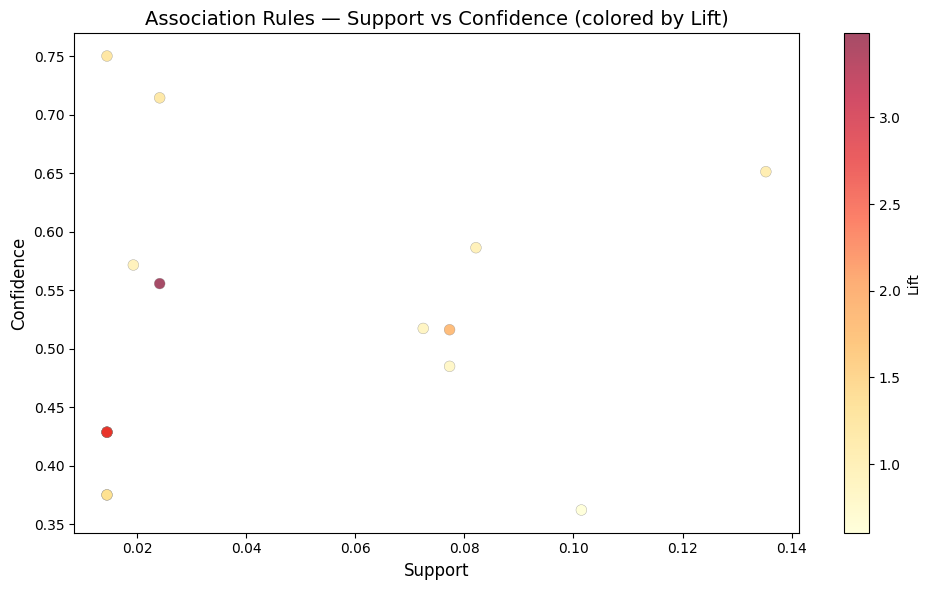

Saved: rules_scatter.png


In [ ]:
#  Support vs Confidence
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    rules_pd["support"],
    rules_pd["confidence"],
    c=rules_pd["lift"],
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="grey",
    linewidths=0.3,
    s=60
)
plt.colorbar(sc, label="Lift")
plt.xlabel("Support", fontsize=12)
plt.ylabel("Confidence", fontsize=12)
plt.title("Association Rules — Support vs Confidence (colored by Lift)", fontsize=14)
plt.tight_layout()
plt.savefig("rules_scatter.png", dpi=150)
plt.show()
print("Saved: rules_scatter.png")

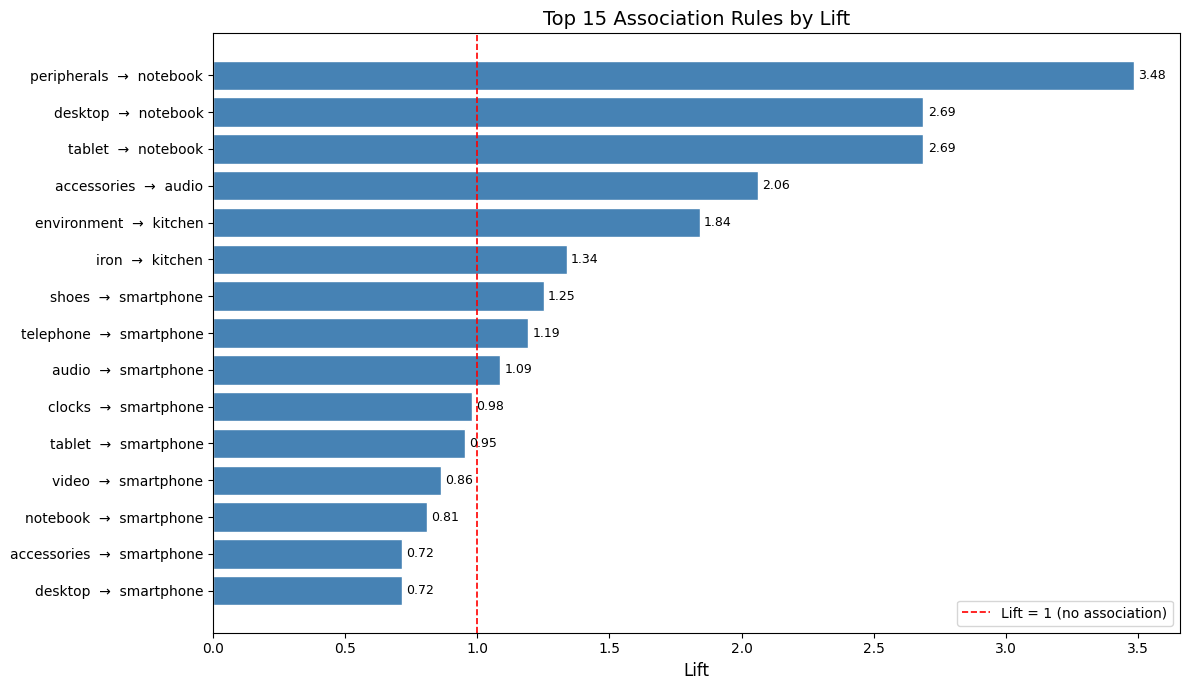

Saved: top15_rules_lift.png


In [ ]:
# Top 15 Rules by Lift horizontal bar chart
top15 = rules_pd.nlargest(15, "lift").copy()
top15["rule"] = top15["antecedent_str"] + "  →  " + top15["consequent_str"]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15["rule"], top15["lift"], color="steelblue", edgecolor="white")
ax.axvline(x=1, color="red", linestyle="--", linewidth=1.2, label="Lift = 1 (no association)")
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.set_xlabel("Lift", fontsize=12)
ax.set_title("Top 15 Association Rules by Lift", fontsize=14)
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.savefig("top15_rules_lift.png", dpi=150)
plt.show()
print("Saved: top15_rules_lift.png")

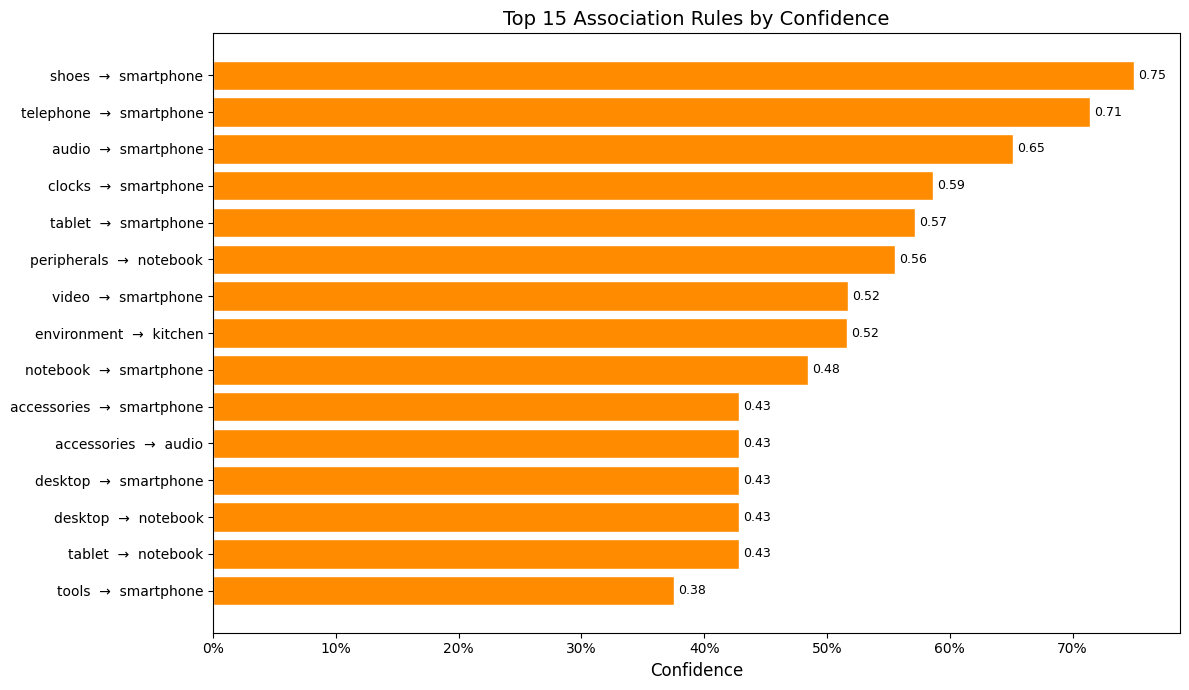

Saved: top15_rules_confidence.png


In [ ]:
top15_conf = rules_pd.nlargest(15, "confidence").copy()
top15_conf["rule"] = top15_conf["antecedent_str"] + "  →  " + top15_conf["consequent_str"]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15_conf["rule"], top15_conf["confidence"], color="darkorange", edgecolor="white")
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Confidence", fontsize=12)
ax.set_title("Top 15 Association Rules by Confidence", fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("top15_rules_confidence.png", dpi=150)
plt.show()
print("Saved: top15_rules_confidence.png")

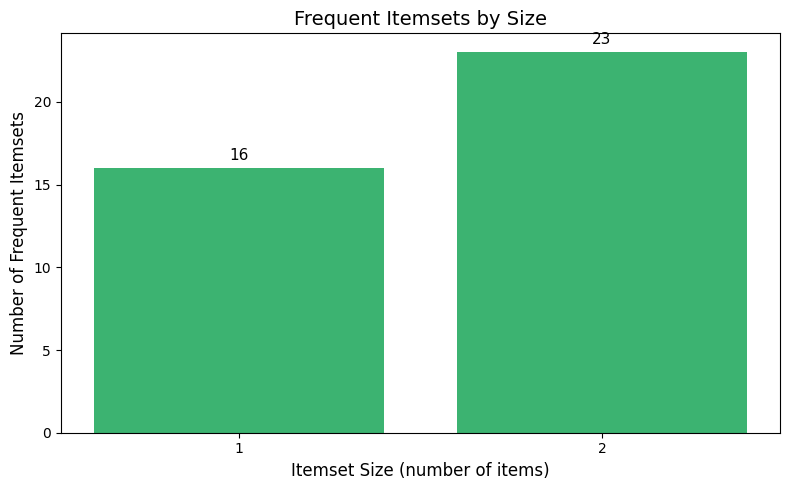

Saved: itemset_size_distribution.png


In [ ]:
# Frequent Itemsets
size_counts = freq_itemsets \
    .groupBy("itemset_size") \
    .count() \
    .orderBy("itemset_size") \
    .toPandas()

plt.figure(figsize=(8, 5))
plt.bar(size_counts["itemset_size"].astype(str), size_counts["count"], color="mediumseagreen")
plt.xlabel("Itemset Size (number of items)", fontsize=12)
plt.ylabel("Number of Frequent Itemsets", fontsize=12)
plt.title("Frequent Itemsets by Size", fontsize=14)
for i, row in size_counts.iterrows():
    plt.text(i, row["count"] + 0.5, str(row["count"]), ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("itemset_size_distribution.png", dpi=150)
plt.show()
print("Saved: itemset_size_distribution.png")

## 9. Experiment: Mine at Category Level

Re-run the pipeline using `category` instead of `product_name` for coarser, more interpretable rules.

In [ ]:
# Build category-level baskets
cat_baskets = (
    events
    .dropna(subset=["user_session", "category"])
    .groupBy("user_session")
    .agg(F.collect_set("category").alias("items"))
    .filter(F.size("items") >= 2)
)

cat_count = cat_baskets.count()
print(f"Category-level transactions: {cat_count:,}")

# FP-Growth on categories with lower support (fewer unique categories → can lower threshold)
fp_cat = FPGrowth(itemsCol="items", minSupport=0.005, minConfidence=0.2)
model_cat = fp_cat.fit(cat_baskets)

print("\n=== Frequent Category Itemsets ===")
model_cat.freqItemsets \
    .withColumn("support", F.col("freq") / cat_count) \
    .orderBy(F.desc("freq")) \
    .show(20, truncate=False)

print("\n=== Category Association Rules (by Lift) ===")
model_cat.associationRules \
    .orderBy(F.desc("lift")) \
    .show(20, truncate=False)

Category-level transactions: 106

=== Frequent Category Itemsets ===
+------------------------------------+----+--------------------+
|items                               |freq|support             |
+------------------------------------+----+--------------------+
|[electronics]                       |92  |0.8679245283018868  |
|[appliances]                        |57  |0.5377358490566038  |
|[appliances, electronics]           |45  |0.42452830188679247 |
|[computers]                         |34  |0.32075471698113206 |
|[computers, electronics]            |27  |0.25471698113207547 |
|[computers, appliances]             |7   |0.0660377358490566  |
|[construction]                      |7   |0.0660377358490566  |
|[auto]                              |7   |0.0660377358490566  |
|[auto, electronics]                 |7   |0.0660377358490566  |
|[kids]                              |5   |0.04716981132075472 |
|[construction, electronics]         |4   |0.03773584905660377 |
|[furniture]         

## 10. Save Results

In [ ]:
freq_itemsets_pd = freq_itemsets \
    .withColumn("items_str", F.concat_ws(" | ", "items")) \
    .select("items_str", "freq", "support", "itemset_size") \
    .toPandas()

freq_itemsets_pd.to_csv("frequent_itemsets.csv", index=False)
rules_pd.to_csv("association_rules.csv", index=False)

print(f"Saved {len(freq_itemsets_pd)} frequent itemsets → frequent_itemsets.csv")
print(f"Saved {len(rules_pd)} association rules   → association_rules.csv")

rules_pd.sort_values("lift", ascending=False).head(10)

Saved 39 frequent itemsets → frequent_itemsets.csv
Saved 17 association rules   → association_rules.csv


,antecedent_str,consequent_str,support,confidence,lift
11,peripherals,notebook,0.024155,0.555556,3.484848
14,tablet,notebook,0.014493,0.428571,2.688312
7,desktop,notebook,0.014493,0.428571,2.688312
2,accessories,audio,0.014493,0.428571,2.063123
3,environment,kitchen,0.077295,0.516129,1.842047
16,iron,kitchen,0.014493,0.375000,1.338362
4,shoes,smartphone,0.014493,0.750000,1.252016
8,telephone,smartphone,0.024155,0.714286,1.192396
15,audio,smartphone,0.135266,0.651163,1.087022
10,clocks,smartphone,0.082126,0.586207,0.978587


In [ ]:
spark.stop()

Spark session stopped.
